소관위원회 모듈러리티 비율 (예시 : 20대 소관위원회 모듈러리티 비율 산출)

In [2]:
import pandas as pd
import networkx as nx
from community import best_partition
from collections import defaultdict
import os

# 노드 데이터 읽기
nodes_df = pd.read_csv(
    r'C:\Users\user\Desktop\경희대\경희대 2-2\소셜네트워크과학\\20대 상임위원회\제20대_법안별_전체데이터_node.csv'
)

# 엣지 데이터 리스트
committee_list = [
    "20대_소관위원회_행정안전위원회.csv",
    "20대_소관위원회_법제사법위원회.csv",
    "20대_소관위원회_국토교통위원회.csv",
    "20대_소관위원회_보건복지위원회.csv",
    "20대_소관위원회_기획재정위원회.csv",
    "20대_소관위원회_정무위원회.csv",
    "20대_소관위원회_산업통상자원중소벤처기업위원회.csv",
    "20대_소관위원회_환경노동위원회.csv",
    "20대_소관위원회_교육위원회.csv",
    "20대_소관위원회_농림축산식품해양수산위원회.csv",
    "20대_소관위원회_문화체육관광위원회.csv",
    "20대_소관위원회_과학기술정보방송통신위원회.csv",
    "20대_소관위원회_국회운영위원회.csv",
    "20대_소관위원회_국방위원회.csv",
    "20대_소관위원회_여성가족위원회.csv",
    "20대_소관위원회_외교통일위원회.csv",
    "20대_소관위원회_정치개혁특별위원회.csv",
    "20대_소관위원회_정보위원회.csv",
    "20대_소관위원회_민생경제안정 특별위원회.csv"
]

# 결과 저장
results = []

# 각 엣지 데이터 파일에 대해 반복
for edge_file_name in committee_list:
    try:
        # 파일 존재 여부 확인
        if not os.path.exists(edge_file_name):
            print(f"파일이 존재하지 않습니다: {edge_file_name}")
            continue

        # 엣지 데이터 읽기
        edge_df = pd.read_csv(edge_file_name)

        # NaN 제거
        edge_df.dropna(subset=['대표발의자', '공동발의자'], inplace=True)

        # 무방향 그래프 생성
        G = nx.Graph()

        # 노드 추가
        for index, row in nodes_df.iterrows():
            G.add_node(row['Id'], Party=row['Party'])

        # 엣지 추가 (중복 엣지 가중치 합산)
        for index, row in edge_df.iterrows():
            if G.has_edge(row['대표발의자'], row['공동발의자']):
                G[row['대표발의자']][row['공동발의자']]['weight'] += 1
            else:
                G.add_edge(row['대표발의자'], row['공동발의자'], weight=1)

        # 정당 모듈러리티 계산 함수
        def calculate_party_modularity(graph, party_partition):
            community_dict = defaultdict(list)
            for node, party in party_partition.items():
                community_dict[party].append(node)
            communities = list(community_dict.values())
            return nx.algorithms.community.quality.modularity(graph, communities, weight='weight')

        # 정당별 커뮤니티 정의
        party_partition = {node: data['Party'] for node, data in G.nodes(data=True)}

        # 정당 모듈러리티 계산
        party_modularity = calculate_party_modularity(G, party_partition)
        print(f"정당 모듈러리티: {party_modularity:.4f}")

        # 최대 모듈러리티 계산 함수
        def calculate_max_modularity(graph):
            partition = best_partition(graph, weight='weight')  # Louvain 알고리즘으로 최적 커뮤니티 탐색
            community_dict = defaultdict(list)
            for node, community in partition.items():
                community_dict[community].append(node)
            communities = list(community_dict.values())
            return nx.algorithms.community.quality.modularity(graph, communities, weight='weight')

        # 최대 모듈러리티 계산
        max_modularity = calculate_max_modularity(G)
        print(f"최대 모듈러리티: {max_modularity:.4f}")

        # 비율 계산
        ratio = party_modularity / max_modularity if max_modularity != 0 else 0
        print(f"비율: {ratio:.4f}")

        # 결과 저장
        results.append({
            "Committee": edge_file_name,
            "Party_Modularity": party_modularity,
            "Max_Modularity": max_modularity,
            "Ratio": ratio
        })

    except Exception as e:
        print(f"오류 발생: {edge_file_name} - {e}")

# 결과를 데이터프레임으로 변환
results_df = pd.DataFrame(results)

# 결과를 CSV로 저장
output_path = '20_modularity_results.csv'
results_df.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"결과가 저장되었습니다: {output_path}")


오류 발생: 20대_소관위원회_행정안전위원회.csv - ['대표발의자', '공동발의자']
정당 모듈러리티: 0.4811
최대 모듈러리티: 0.4913
비율: 0.9792
정당 모듈러리티: 0.4769
최대 모듈러리티: 0.4859
비율: 0.9814
정당 모듈러리티: 0.4701
최대 모듈러리티: 0.4797
비율: 0.9799
정당 모듈러리티: 0.4834
최대 모듈러리티: 0.4966
비율: 0.9735
오류 발생: 20대_소관위원회_정무위원회.csv - ['대표발의자', '공동발의자']
정당 모듈러리티: 0.4849
최대 모듈러리티: 0.5099
비율: 0.9509
정당 모듈러리티: 0.4631
최대 모듈러리티: 0.4823
비율: 0.9603
정당 모듈러리티: 0.4410
최대 모듈러리티: 0.4564
비율: 0.9663
정당 모듈러리티: 0.4357
최대 모듈러리티: 0.4621
비율: 0.9428
오류 발생: 20대_소관위원회_문화체육관광위원회.csv - ['대표발의자', '공동발의자']
정당 모듈러리티: 0.4628
최대 모듈러리티: 0.4844
비율: 0.9554
정당 모듈러리티: 0.4759
최대 모듈러리티: 0.4892
비율: 0.9729
정당 모듈러리티: 0.4816
최대 모듈러리티: 0.5000
비율: 0.9631
오류 발생: 20대_소관위원회_여성가족위원회.csv - ['대표발의자', '공동발의자']
정당 모듈러리티: 0.4581
최대 모듈러리티: 0.4820
비율: 0.9504
파일이 존재하지 않습니다: 20대_소관위원회_정치개혁특별위원회.csv
오류 발생: 20대_소관위원회_정보위원회.csv - ['대표발의자', '공동발의자']
파일이 존재하지 않습니다: 20대_소관위원회_민생경제안정 특별위원회.csv
결과가 저장되었습니다: 20_modularity_results.csv


소관위원회별 동일당끼리 협력지수 (예시 : 21대 소관위원회 정의당끼리의 협력지수)

In [7]:
import pandas as pd

# CSV 데이터를 읽어옵니다
df = pd.read_csv(r'C:\Users\user\Desktop\경희대\경희대 2-2\소셜네트워크과학\20대 상임위원회\제20대_혼합성지수_협력지수_결과.csv')  # 파일 경로를 수정하세요

# '국민의당'이 대표발의자_정당 또는 공동발의자_정당에 포함된 데이터 필터링
filtered_df = df[(df['대표발의자_정당'] == '정의당') & (df['공동발의자_정당'] == '정의당')]

# 각 파일명별로 그룹화
grouped = filtered_df.groupby('파일명')

# 최종 결과를 저장할 리스트
final_rows = []

# 그룹별로 처리
for file_name, group in grouped:
    # 협력지수 평균 계산
    mean_cooperation = group['협력지수'].mean()
    
    # 원본 데이터 추가
    final_rows.append(group)
    

# 모든 그룹을 합쳐 최종 데이터프레임 생성
final_df = pd.concat(final_rows, ignore_index=True)

# 결과를 CSV 파일로 저장
final_df.to_csv('정의당_filtered_with_averages.csv', index=False)

# 결과 출력
print(final_df)


   대표발의자_정당 공동발의자_정당      협력지수                            파일명  평균_혼합성지수
0       정의당      정의당  0.407797    20대_소관위원회_과학기술정보방송통신위원회.csv  0.146065
1       정의당      정의당  0.530175            20대_소관위원회_교육위원회.csv  0.111079
2       정의당      정의당  0.507766            20대_소관위원회_국방위원회.csv  0.149612
3       정의당      정의당  0.344264          20대_소관위원회_국토교통위원회.csv  0.112551
4       정의당      정의당  0.478275          20대_소관위원회_국회운영위원회.csv  0.131833
5       정의당      정의당  0.538007          20대_소관위원회_기획재정위원회.csv  0.114933
6       정의당      정의당  0.413803    20대_소관위원회_농림축산식품해양수산위원회.csv  0.199380
7       정의당      정의당  0.213980        20대_소관위원회_문화체육관광위원회.csv  0.136793
8       정의당      정의당  0.412571          20대_소관위원회_법제사법위원회.csv  0.121819
9       정의당      정의당  0.466091          20대_소관위원회_보건복지위원회.csv  0.136725
10      정의당      정의당  0.461593  20대_소관위원회_산업통상자원중소벤처기업위원회.csv  0.103672
11      정의당      정의당  0.216295          20대_소관위원회_여성가족위원회.csv  0.121837
12      정의당      정의당  0.352454          20대_소관위원회_외교통일위원회.csv  0

소관위원회별 노드 중요도 계산식(샤넌 알고리즘 활용)

In [8]:
import pandas as pd
import numpy as np

# Load the main dataset
data_path = r"C:\Users\user\Desktop\경희대\경희대 2-2\소셜네트워크과학\21대 상임위원회\제21대_전체데이터_무소속변경.csv"  # Replace with your actual file path
df_main = pd.read_csv(data_path)

# Load the ID data (list of all nodes)
id_data_path = r"C:\Users\user\Desktop\경희대\경희대 2-2\소셜네트워크과학\21대 상임위원회\제21대_법안별_전체데이터_node.csv"  # Replace with your actual file path
df_id = pd.read_csv(id_data_path)

# Create a directed graph structure from the Source and Target columns
source_target_pairs = df_main[['Source', 'Target', '대표발의자_정당', '공동발의자_정당']]

# Initialize a dictionary to hold entropy values
entropy_values = {}

# Calculate party connection proportions and entropy for each node
for node in df_id['Id']:
    party_counts = {}

    # Count outgoing edges
    outgoing = source_target_pairs[source_target_pairs['Source'] == node]
    for _, row in outgoing.iterrows():
        party = row['공동발의자_정당']
        party_counts[party] = party_counts.get(party, 0) + 1

    # Count incoming edges
    incoming = source_target_pairs[source_target_pairs['Target'] == node]
    for _, row in incoming.iterrows():
        party = row['대표발의자_정당']
        party_counts[party] = party_counts.get(party, 0) + 1

    # Calculate total connections
    total_connections = sum(party_counts.values())

    # Compute entropy if there are connections
    if total_connections > 0:
        proportions = [count / total_connections for count in party_counts.values()]
        entropy = -sum(p * np.log2(p) for p in proportions)
    else:
        entropy = 0

    entropy_values[node] = entropy

# Add entropy values to the ID dataframe
df_id['Importance'] = df_id['Id'].map(entropy_values)

# Save the result to a CSV file
output_path = r"21대_node_importance_with_entropy.csv"
df_id.to_csv(output_path, index=False)

print(df_id)
print(f"Results saved to {output_path}.")


      Id Label   Party Reselection District_Type Gender            Role  \
0    신정훈   신정훈  더불어민주당          재선           지역구      남  Representative   
1    박성중   박성중    국민의힘          재선           지역구      남  Representative   
2    김정호   김정호  더불어민주당          재선           지역구      남  Representative   
3    강은미   강은미     정의당          초선          비례대표      여  Representative   
4    윤건영   윤건영  더불어민주당          초선           지역구      남  Representative   
..   ...   ...     ...         ...           ...    ...             ...   
314  최종윤   최종윤  더불어민주당          초선           지역구      남  Representative   
315  권인숙   권인숙  더불어민주당          초선          비례대표      여  Representative   
316  김용판   김용판    국민의힘          초선           지역구      남  Representative   
317  강성희   강성희     진보당          초선           지역구      남  Representative   
318  송석준   송석준    국민의힘          재선           지역구      남  Representative   

     Importance  
0      0.127793  
1      0.113660  
2      0.247558  
3      1.691881  
4      0.

소관위원회별 노드 betweenness

In [11]:
import pandas as pd
import networkx as nx
import os

# 엣지 데이터 리스트
committee_list = [
    "21대_소관위원회_행정안전위원회.csv",
    "21대_소관위원회_법제사법위원회.csv",
    "21대_소관위원회_국토교통위원회.csv",
    "21대_소관위원회_보건복지위원회.csv",
    "21대_소관위원회_기획재정위원회.csv",
    "21대_소관위원회_정무위원회.csv",
    "21대_소관위원회_산업통상자원중소벤처기업위원회.csv",
    "21대_소관위원회_환경노동위원회.csv",
    "21대_소관위원회_교육위원회.csv",
    "21대_소관위원회_농림축산식품해양수산위원회.csv",
    "21대_소관위원회_문화체육관광위원회.csv",
    "21대_소관위원회_과학기술정보방송통신위원회.csv",
    "21대_소관위원회_국회운영위원회.csv",
    "21대_소관위원회_국방위원회.csv",
    "21대_소관위원회_여성가족위원회.csv",
    "21대_소관위원회_외교통일위원회.csv",
    "21대_소관위원회_정치개혁특별위원회.csv",
    "21대_소관위원회_정보위원회.csv",
    "21대_소관위원회_민생경제안정 특별위원회.csv"
]

# 결과를 저장할 리스트
results = []

for edge_file in committee_list:
    # 파일 존재 여부 확인
    if not os.path.exists(edge_file):
        print(f"파일이 존재하지 않습니다: {edge_file}")
        continue

    print(f"Processing: {edge_file}")

    try:
        # 데이터 로드
        data = pd.read_csv(edge_file, encoding="utf-8-sig")

        # 필수 열 확인
        required_columns = ['대표발의자', '공동발의자', '대표발의자_정당', '공동발의자_정당']
        if not all(col in data.columns for col in required_columns):
            print(f"필수 열이 누락되었습니다: {edge_file}")
            continue

        # NaN 제거
        data.dropna(subset=required_columns, inplace=True)

        # 방향 그래프 생성
        G = nx.DiGraph()

        # 그래프에 노드와 엣지 추가
        for _, row in data.iterrows():
            # 대표발의자와 공동발의자를 노드로 추가
            G.add_node(row['대표발의자'], 정당=row['대표발의자_정당'])
            G.add_node(row['공동발의자'], 정당=row['공동발의자_정당'])
            # 대표발의자와 공동발의자 간 엣지 추가
            G.add_edge(row['대표발의자'], row['공동발의자'])

        # Betweenness Centrality 계산
        betweenness = nx.betweenness_centrality(G, normalized=True, weight=None)

        # 결과를 DataFrame으로 변환
        betweenness_df = pd.DataFrame(list(betweenness.items()), columns=["노드", "Betweenness"])

        # 소관위원회 이름 추가
        committee_name = edge_file.split('_')[-1].replace('.csv', '')
        betweenness_df['소관위원회'] = committee_name

        # 결과를 리스트에 추가
        results.append(betweenness_df)

    except Exception as e:
        print(f"파일 처리 중 에러 발생: {edge_file}, 에러: {e}")
        continue

# 모든 결과를 하나의 DataFrame으로 병합
if results:
    final_results_df = pd.concat(results, ignore_index=True)
    # 결과를 CSV로 저장
    final_results_df.to_csv("제21대_소관위원회_Betweenness_결과.csv", index=False, encoding="utf-8-sig")
    print("모든 소관위원회 Betweenness centrality 결과가 '제21대_소관위원회_Betweenness_결과.csv'로 저장되었습니다.")
else:
    print("처리된 데이터가 없습니다.")

print(final_results_df)


Processing: 21대_소관위원회_행정안전위원회.csv
Processing: 21대_소관위원회_법제사법위원회.csv
Processing: 21대_소관위원회_국토교통위원회.csv
Processing: 21대_소관위원회_보건복지위원회.csv
Processing: 21대_소관위원회_기획재정위원회.csv
Processing: 21대_소관위원회_정무위원회.csv
Processing: 21대_소관위원회_산업통상자원중소벤처기업위원회.csv
Processing: 21대_소관위원회_환경노동위원회.csv
Processing: 21대_소관위원회_교육위원회.csv
Processing: 21대_소관위원회_농림축산식품해양수산위원회.csv
Processing: 21대_소관위원회_문화체육관광위원회.csv
Processing: 21대_소관위원회_과학기술정보방송통신위원회.csv
Processing: 21대_소관위원회_국회운영위원회.csv
Processing: 21대_소관위원회_국방위원회.csv
Processing: 21대_소관위원회_여성가족위원회.csv
Processing: 21대_소관위원회_외교통일위원회.csv
Processing: 21대_소관위원회_정치개혁특별위원회.csv
Processing: 21대_소관위원회_정보위원회.csv
Processing: 21대_소관위원회_민생경제안정 특별위원회.csv
모든 소관위원회 Betweenness centrality 결과가 '제21대_소관위원회_Betweenness_결과.csv'로 저장되었습니다.
       노드  Betweenness         소관위원회
0     문진석     0.004499       행정안전위원회
1     서영석     0.000511       행정안전위원회
2     송재호     0.015629       행정안전위원회
3     정성호     0.001973       행정안전위원회
4     이정문     0.000606       행정안전위원회
...   ...          ...           

최종 노드 중요도 = 샤넌 알고리즘 x 노드 betweenness

In [12]:
import pandas as pd

# Load the first dataset
betweenness_data = pd.read_csv(r"C:\Users\user\Desktop\경희대\경희대 2-2\소셜네트워크과학\21대 상임위원회\제21대_소관위원회_Betweenness_결과.csv")

# Load the second dataset
id_data = pd.read_csv(r"C:\Users\user\Desktop\경희대\경희대 2-2\소셜네트워크과학\21대_node_importance_with_entropy.csv")

# Merge the datasets on matching Id and 노드
merged_data = pd.merge(betweenness_data, id_data, left_on="노드", right_on="Id", how="inner")

# Calculate the final importance
merged_data["Final_Importance"] = merged_data["Betweenness"] * merged_data["Importance"]

# Save the resulting DataFrame to a CSV file
output_path = "21대_최종노드_중요도.csv"
merged_data.to_csv(output_path, index=False)

print(f"Results saved to {output_path}.")
print(merged_data)

Results saved to 21대_최종노드_중요도.csv.
       노드  Betweenness         소관위원회   Id Label   Party Reselection  \
0     문진석     0.004499       행정안전위원회  문진석   문진석  더불어민주당          초선   
1     서영석     0.000511       행정안전위원회  서영석   서영석  더불어민주당          초선   
2     송재호     0.015629       행정안전위원회  송재호   송재호  더불어민주당          초선   
3     정성호     0.001973       행정안전위원회  정성호   정성호  더불어민주당          4선   
4     이정문     0.000606       행정안전위원회  이정문   이정문  더불어민주당          초선   
...   ...          ...           ...  ...   ...     ...         ...   
5589  백종헌     0.000000  민생경제안정 특별위원회  백종헌   백종헌    국민의힘          초선   
5590  안병길     0.000000  민생경제안정 특별위원회  안병길   안병길    국민의힘          초선   
5591  이종배     0.000000  민생경제안정 특별위원회  이종배   이종배    국민의힘          3선   
5592  이헌승     0.000000  민생경제안정 특별위원회  이헌승   이헌승    국민의힘          3선   
5593  전봉민     0.000000  민생경제안정 특별위원회  전봉민   전봉민    국민의힘          초선   

     District_Type Gender            Role  Importance  Final_Importance  
0              지역구      남  Representat

소관워원회별 초선 vs 다선 데이터 (예시 : 21대 소관위원회 데이터)

열 이름: Index(['노드', 'Betweenness', '소관위원회', 'Id', 'Label', 'Party', 'Reselection',
       'District_Type', 'Gender', 'Role', 'Importance', 'Final_Importance'],
      dtype='object')
       노드  Betweenness         소관위원회   Id Label   Party Reselection  \
60    최연숙     0.107770       여성가족위원회  최연숙   최연숙    국민의당       초선/재선   
61    김홍걸     0.060770       여성가족위원회  김홍걸   김홍걸  더불어민주당       초선/재선   
62    조은희     0.060443       여성가족위원회  조은희   조은희    국민의힘       초선/재선   
64    윤영덕     0.039080       여성가족위원회  윤영덕   윤영덕  더불어민주당       초선/재선   
4432  강민정     0.019019       여성가족위원회  강민정   강민정   열린민주당       초선/재선   
...   ...          ...           ...  ...   ...     ...         ...   
40    김민석     0.001266  민생경제안정 특별위원회  김민석   김민석  더불어민주당       3선/4선   
41    배준영     0.001424  민생경제안정 특별위원회  배준영   배준영    국민의힘       초선/재선   
42    조수진     0.001108  민생경제안정 특별위원회  조수진   조수진    국민의힘       초선/재선   
43    신영대     0.000000  민생경제안정 특별위원회  신영대   신영대  더불어민주당       초선/재선   
5514  강민정     0.000000  민생경제안정 특별위원회  

C:\Users\user\AppData\Local\Temp\ipykernel_10024\2438870127.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('소관위원회').apply(lambda x: x.nlargest(5, 'Final_Importance')).reset_index(drop=True)


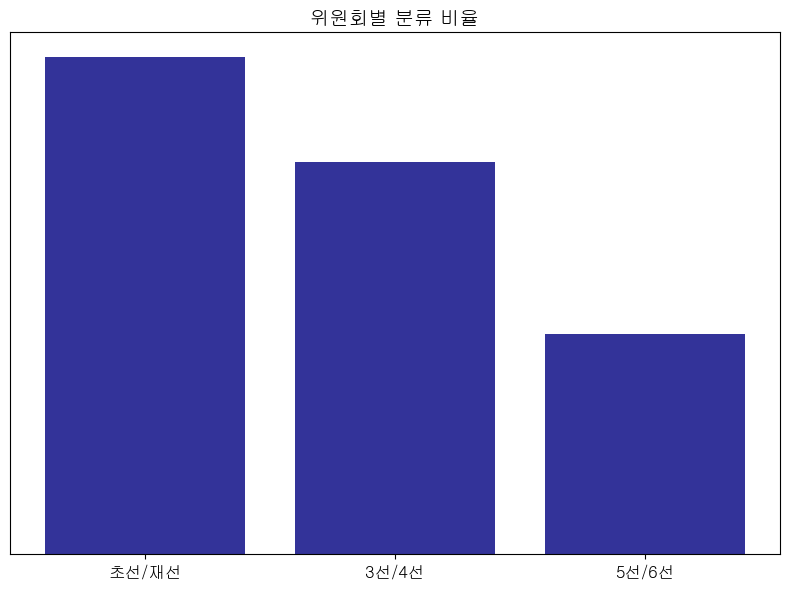

In [13]:
import pandas as pd
import os

# 초선/재선, 3선/4선, 5선/6선 분류 함수
def categorize_term(term):
    if term in ["초선", "재선"]:
        return '초선/재선'
    elif term in ["3선", "4선"]:
        return '3선/4선'
    elif term in ["5선", "6선"]:
        return '5선/6선'
    else:
        return '기타'

# 위원회별로 상위 5명 선정
def top_5_per_committee(df):
    return df.groupby('소관위원회').apply(lambda x: x.nlargest(5, 'Final_Importance')).reset_index(drop=True)

# 중복 처리: 더 높은 중요도를 가진 의원만 남기기
def remove_duplicates(df):
    # 중요도가 가장 높은 경우만 유지
    df = df.sort_values(by='Final_Importance', ascending=False)
    unique_members = df.drop_duplicates(subset=['노드'], keep='first')
    return unique_members

# 제외된 위원회에서 대체 인원 추가
def fill_missing(df, original_df, top_n=5):
    final_df = []
    
    for committee in df['소관위원회'].unique():
        # 해당 위원회의 남은 인원
        current_committee = df[df['소관위원회'] == committee]
        original_committee = original_df[original_df['소관위원회'] == committee]
        
        # 현재 남은 인원 수 계산
        missing_count = top_n - len(current_committee)

        if missing_count > 0:
            # 제외된 인원 순위 추가
            remaining_candidates = original_committee[~original_committee['노드'].isin(current_committee['노드'])]
            additional_members = remaining_candidates.nlargest(missing_count, 'Final_Importance')
            current_committee = pd.concat([current_committee, additional_members])

        final_df.append(current_committee)

    return pd.concat(final_df)

# 모든 CSV 파일 처리
def process_all_committees():
    all_results = []

    # 데이터 읽기
    file_path = r"C:\\Users\\user\\Desktop\\경희대\\경희대 2-2\\소셜네트워크과학\\21대 상임위원회\\21대_최종노드_중요도.csv"
    df = pd.read_csv(file_path, encoding='utf-8')  # 인코딩 확인
    
    # 열 이름 확인
    print("열 이름:", df.columns)

    # 분류 추가
    df['Reselection'] = df['Reselection'].apply(categorize_term)
    
    # 상위 5명 선정
    top_5_df = top_5_per_committee(df)
    
    # 중복 제거
    unique_df = remove_duplicates(top_5_df)
    
    # 대체 인원 추가
    final_df = fill_missing(unique_df, df)
    
    # 결과 저장
    all_results.append(final_df)

    # 모든 결과 합치기
    combined_results = pd.concat(all_results)
    return combined_results

# 처리 실행
final_results = process_all_committees()

# 결과 저장
final_results.to_csv("21_final_committee_results.csv", index=False, encoding='utf-8-sig')

# 결과 출력
print(final_results)

import pandas as pd

df = pd.read_csv(r"C:\Users\user\Desktop\경희대\경희대 2-2\소셜네트워크과학\21_final_committee_results.csv")

# 각 범주의 개수 계산
category_counts = df['Reselection'].value_counts()

# 결과 출력
print(category_counts)



import matplotlib.pyplot as plt
import numpy as np

# Data
categories = ["초선/재선", "3선/4선", "5선/6선"]
overall = np.array([245, 63, 16])
committee = np.array([69, 14, 2])

# 한글 폰트 설정
plt.rcParams["font.family"] = 'Gulim'

# Calculating the ratio
ratios = committee / overall

# Plotting
plt.figure(figsize=(8, 6))
plt.bar(categories, ratios, color='navy', alpha=0.8)

# Customizing the plot
plt.xticks(rotation=0, fontname="Gulim", fontsize=12)
plt.gca().yaxis.set_visible(False)  # Hiding the y-axis labels
plt.title("위원회별 분류 비율", fontname="Gulim", fontsize=14)
plt.tight_layout()

# Display the plot
plt.show()
